In [1]:
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import pandas as pd
import math
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.layers import Attention

tf.random.set_seed(666)


In [2]:
# Single step dataset preparation
def singleStepSampler(df, window):
	xRes = []
	yRes = []
	for i in range(0, len(df) - window):
		res = []
		for j in range(0, window):
			r = []
			for col in df.columns:
				r.append(df[col][i + j])
			res.append(r)
		xRes.append(res)
		yRes.append(df[['dis']].iloc[i + window].values)
	return np.array(xRes), np.array(yRes)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [106]:
# Dataset loading
name = '3_xhl_imputMF_monthly'
csv_path = f"/content/drive/MyDrive/river_runoff_obs/{name}.csv"
# usecols = ['time', 'pre', 'tm', 'tmax', 'tmin',  'dis']
usecols = ['time', 'pre', 'tm','dis']

dataFrame_full = pd.read_csv(csv_path, usecols=usecols)
# this refers to observed runoff and 10d_mean refers to the runoff with MA

In [107]:
# Get Index of NaN Values in a Specific Column:

# Create a boolean series that identifies NaN values
is_null = dataFrame_full['dis'].isnull()


# Shift the boolean series to identify changes between NaN and non-NaN values
shifted = is_null.ne(is_null.shift()).cumsum()

# Group by the shifted series and filter to only NaN sections
nan_sections = dataFrame_full[is_null].groupby(shifted)

# Extract the start and end indices for each section and create separate lists for them
start_indices = []
end_indices = []

for _, group in nan_sections:
    start_indices.append(group.index[0])
    end_indices.append(group.index[-1])

# Create a DataFrame from the lists
null_index_df = pd.DataFrame({'Start': start_indices, 'End': end_indices})

In [108]:
null_index_df

,Start,End
0,132,136
1,141,148
2,600,647
3,694,731


In [109]:
def intercept_data(i):
	global dataFrame
	# Intercept the first section of missing value
	# dataFrame = dataFrame_full[ :null_index_df["End"][i]+365]
	dataFrame = dataFrame_full[ :null_index_df["End"][i]+1]

In [110]:
def scaler_data(dataFrame ):
	global scaler
	imputer = SimpleImputer(missing_values=np.nan) # Handling missing values
	if 'time' in dataFrame.columns:
		dataFrame.drop(columns=['time'], inplace=True)
	dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
	dataFrame = dataFrame.reset_index(drop=True)
	# Applying feature scaling
	scaler = MinMaxScaler(feature_range=(0, 1))
	df_scaled = scaler.fit_transform(dataFrame.to_numpy())
	df_scaled = pd.DataFrame(df_scaled, columns=list(dataFrame.columns))
	target_scaler = MinMaxScaler(feature_range=(0, 1))
	df_scaled[ ['dis']] = target_scaler.fit_transform(dataFrame[ ['dis']].to_numpy())
	df_scaled = df_scaled.astype(float)

	return df_scaled

In [111]:
# def scaler_data(dataFrame):
#     global scaler
#
#     # Handling missing values with SimpleImputer
#     imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
#     if 'time' in dataFrame.columns:
#         dataFrame.drop(columns=['time'], inplace=True)
#
#     # Impute missing values
#     dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
#     dataFrame = dataFrame.reset_index(drop=True)
#
#     # Separate features and target (assuming 'dis' is the target)
#     features = dataFrame.drop(columns=['dis'])
#     target = dataFrame[['dis']]
#
#     # Apply MaxAbsScaler to features
#     scaler = MaxAbsScaler()
#     features_scaled = scaler.fit_transform(features)
#
#     # Apply MinMaxScaler to the target column ('dis')
#     target_scaler = MinMaxScaler(feature_range=(0, 1))
#     target_scaled = target_scaler.fit_transform(target)
#
#     # Combine the scaled features and target back into a DataFrame
#     df_scaled = pd.DataFrame(features_scaled, columns=features.columns)
#     df_scaled['dis'] = target_scaled  # Add the scaled target back
#
#     # Ensure all values are float type
#     df_scaled = df_scaled.astype(float)
#
#     return df_scaled

In [112]:
## Data spliting

In [113]:
def split_data(df_scaled ,i):

	# Dataset splitting
	SPLIT = 0.7 # Equal to the rate by Pr. Wang Lei train_data_rate = 0.7

	(xVal, yVal) = singleStepSampler(df_scaled, time_step)
	X_train =    xVal[:int(SPLIT * len(xVal))]
	y_train =    yVal[:int(SPLIT * len(yVal))]
	X_test =     xVal[int(SPLIT * len(xVal)):]
	y_test =     yVal[int(SPLIT * len(yVal)):]

	X_forecast = xVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] # For singleStepSampler, the time step need to be added.
	# X_forecast = xVal[:] # We will use the whole dataset for forecast
	yVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] = 0
	"""Whether or not as the following"""
	# X_forecast = xVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] # For singleStepSampler, the time step need to be added.

	return X_train, y_train, X_test, y_test ,X_forecast

In [114]:
# X_train, y_train, X_test, y_test , X_forecast = split_data(df_scaled,i)

In [115]:
# null_index_df["Start"][0] - null_index_df["End"][0]

In [116]:
# def model_building(X_train):
# 	multivariate_lstm = keras.Sequential()
# 	multivariate_lstm.add(keras.layers.LSTM(200, input_shape=(X_train.shape[1], X_train.shape[2])))
# 	multivariate_lstm.add(keras.layers.Dropout(0.4))
# 	multivariate_lstm.add(keras.layers.Dense(1, activation='linear')) # Only output the ET
# 	multivariate_lstm.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
# 	multivariate_lstm.summary()
# 	return multivariate_lstm

In [117]:
# def model_building(X_train):
# 	multivariate_lstm = keras.Sequential()
# 	multivariate_lstm.add(keras.layers.LSTM(200, input_shape=(X_train.shape[1], X_train.shape[2])))
# 	multivariate_lstm.add(keras.layers.Dropout(0.4))
# 	multivariate_lstm.add(keras.layers.Dense(50, activation='linear')) # Only output the ET
# 	multivariate_lstm.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
# 	multivariate_lstm.summary()

# 	# Early stopping callback
# 	early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# 	return multivariate_lstm

In [118]:
# """use bidirectional LSTM"""
# from keras.layers import Bidirectional
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()

#     # Add a bidirectional LSTM layer
#     multivariate_lstm.add(Bidirectional(keras.layers.LSTM(200, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output

#     # Compile the model
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()

#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm

In [119]:
# from keras.models import Sequential
# from keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dropout, Dense, Flatten
# from keras.optimizers import Adam
# from keras.callbacks import EarlyStopping
# from bayes_opt import BayesianOptimization
# import numpy as np
#
# def model_building(X_train):
#     model = Sequential()
#
#     # Add 1D Convolutional layers for feature extraction
#     model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#     model.add(MaxPooling1D(pool_size=2))
#
#     # Add Bi-directional LSTM layer for temporal dependencies
#     model.add(Bidirectional(LSTM(200, return_sequences=False)))
#
#     # Dropout layer for regularization
#     model.add(Dropout(0.4))
#
#     # Dense layers for further learning
#     model.add(Dense(100, activation='relu'))
#     model.add(Dense(50, activation='linear'))  # Output layer for runoff forecast
#
#     # Compile the model
#     model.compile(optimizer=Adam(), loss='MeanSquaredError', metrics=['MAE'])
#
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#
#     model.summary()
#     return model
#
# # VMD Step
# def vmd_decomposition(data):
#     # Perform Variational Mode Decomposition (VMD) here
#     # This will output multiple decomposed signals that can be used as input features
#     decomposed_modes = []  # Placeholder for decomposed signals
#     # Implement VMD decomposition here, or use a library
#     return np.array(decomposed_modes)
#
# # Bayes Optimization for hyperparameter tuning
# def optimize_model(X_train, y_train):
#     def model_evaluate(lstm_units, dropout_rate, conv_filters):
#         model = Sequential()
#
#         # CNN layers
#         model.add(Conv1D(filters=int(conv_filters), kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#         model.add(MaxPooling1D(pool_size=2))
#
#         # BiLSTM layer
#         model.add(Bidirectional(LSTM(int(lstm_units), return_sequences=False)))
#
#         # Dropout layer
#         model.add(Dropout(dropout_rate))
#
#         # Dense layers
#         model.add(Dense(100, activation='relu'))
#         model.add(Dense(50, activation='linear'))  # Output layer
#
#         # Compile the model
#         model.compile(optimizer=Adam(), loss='MeanSquaredError', metrics=['MAE'])
#
#         # Train and evaluate the model
#         model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)  # Dummy training for optimization purposes
#
#         # Evaluation metric (can be MAE or validation loss)
#         mae = model.evaluate(X_train, y_train, verbose=0)[1]
#         return -mae  # Minimize the MAE (or other metric)
#
#     # Define the parameter space for Bayes Optimization
#     pbounds = {
#         'lstm_units': (50, 300),
#         'dropout_rate': (0.2, 0.5),
#         'conv_filters': (32, 128)
#     }
#
#     optimizer = BayesianOptimization(
#         f=model_evaluate,
#         pbounds=pbounds,
#         random_state=42
#     )
#
#     optimizer.maximize(init_points=10, n_iter=50)
#
#     best_params = optimizer.max['params']
#     return best_params
#
# # Example usage
# # X_train and y_train should be the processed and decomposed data
# X_train_decomposed = vmd_decomposition(X_train)  # Apply VMD
# best_params = optimize_model(X_train_decomposed, y_train)  # Optimize the model with BOA
#
# # Build the final model with best parameters found by BOA
# final_model = model_building(X_train_decomposed)


In [120]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#     # Add more layers or units to increase capacity
#     multivariate_lstm.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.LSTM(128))
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     # Add additional dense layers
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output layer
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
#
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm


In [121]:
# # model source https://www.nature.com/articles/s41598-024-63989-7#Sec2
# import tensorflow as tf
# from tensorflow.keras import layers, models
#
# def model_building(X_train):
#     multivariate_lstm = models.Sequential()
#
#     # First LSTM layer with 512 neurons and ReLU activation
#     multivariate_lstm.add(layers.LSTM(units=512, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Second LSTM layer with a progressive reduction in neurons
#     multivariate_lstm.add(layers.LSTM(units=256, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Third LSTM layer with further reduction in neurons
#     multivariate_lstm.add(layers.LSTM(units=128, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Fourth LSTM layer with 64 neurons
#     multivariate_lstm.add(layers.LSTM(units=64, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Fifth LSTM layer with 32 neurons
#     multivariate_lstm.add(layers.LSTM(units=32, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Sixth LSTM layer with 16 neurons
#     multivariate_lstm.add(layers.LSTM(units=16, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Seventh LSTM layer with 8 neurons
#     multivariate_lstm.add(layers.LSTM(units=8, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Eighth LSTM layer with 4 neurons
#     multivariate_lstm.add(layers.LSTM(units=4, return_sequences=False))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Output layer with 1 neuron for the prediction of runoff
#     multivariate_lstm.add(layers.Dense(units=1))
#
#     # Compile the model using Adam optimizer and MSE as loss function
#     optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
#     multivariate_lstm.compile(optimizer=optimizer, loss='mean_squared_error')
#
#     return multivariate_lstm


In [122]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#
#     # LSTM layer
#     multivariate_lstm.add(keras.layers.LSTM(200, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#
#     # Attention mechanism
#     attention = Attention()
#     multivariate_lstm.add(attention)
#
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))
#
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
#
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm

In [123]:
"""Add CNN Layer"""
def model_building(X_train):
    multivariate_lstm = keras.Sequential()

    # Add a CNN layer
    multivariate_lstm.add(keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    multivariate_lstm.add(keras.layers.MaxPooling1D(pool_size=2))

    # Add LSTM layers
    multivariate_lstm.add(keras.layers.LSTM(200, return_sequences=True))
    multivariate_lstm.add(keras.layers.LSTM(150))

    multivariate_lstm.add(keras.layers.Dropout(0.4))
    multivariate_lstm.add(keras.layers.Dense(250, activation='linear'))

    multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
    return multivariate_lstm

In [124]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#
#     # LSTM layers with increased capacity
#     multivariate_lstm.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.LSTM(128))
#
#     # Dropout for regularization
#     multivariate_lstm.add(keras.layers.Dropout(0.5))
#
#     # Add dense layers for better learning
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output
#
#     # Compile the model with an adjusted learning rate
#     optimizer = Adam(learning_rate=0.001)
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer=optimizer)
#     multivariate_lstm.summary()
#
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#
#     return multivariate_lstm

In [125]:
# # Model training
# def model_training(multivariate_lstm,X_train, y_train, X_test, y_test):
# 	history = multivariate_lstm.fit(X_train, y_train, epochs= 1000)
# 	return multivariate_lstm

In [126]:
def model_training(multivariate_lstm, X_train, y_train, X_test, y_test):
    # Define early stopping to avoid overfitting
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=50, restore_best_weights=True)

    # Train the model
    history = multivariate_lstm.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=128,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        verbose=1  # Optional, to display training progress
    )

    # Return both the trained model and the training history
    return multivariate_lstm, history


In [127]:
# def medel_predict(multivariate_lstm,  X_test, y_test):
# 	global predicted_values,X_test_predicted_df
#
# 	dataFrame = dataFrame_full[ :null_index_df["End"][i]]# Assuming the CSV file contains a 'Date' column
# 	# dataFrame['time'] = pd.to_datetime(dataFrame['time'])
# 	dataFrame.set_index('time', inplace=True)
#
# 	# Forecast Plot with Dates on X-axis
# 	predicted_values = multivariate_lstm.predict(X_test)
#
# 	d = {
# 		'Actual_runoff': y_test.ravel(),
# 		'Predicted_runoff': predicted_values.ravel()
# 	}
# 	d = pd.DataFrame(d)
# 	d.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
# 	return d

In [128]:
def medel_predict(multivariate_lstm,  X_test, y_test):
	global predicted_values,X_test_predicted_df

	dataFrame = dataFrame_full[ :null_index_df["End"][i]]# Assuming the CSV file contains a 'Date' column
	# dataFrame['time'] = pd.to_datetime(dataFrame['time'])
	dataFrame.set_index('time', inplace=True)

	# Forecast Plot with Dates on X-axis
	predicted_values = multivariate_lstm.predict(X_test)

	if len(predicted_values.shape)== 1 or predicted_values.shape[-1] == 1:
		d = {
		'Actual_runoff': y_test.ravel(),
		'Predicted_runoff': predicted_values.ravel()
	}
	else:
		d = {
		'Actual_runoff': y_test.ravel(),
		'Predicted_runoff': predicted_values[:,time_step-1]
	}
	d = pd.DataFrame(d)
	d.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_test{i}.csv")
	return d

In [129]:
# predicted_values.shape[-1]

In [130]:
	# d=medel_predict(multivariate_lstm,  X_test, y_test)


In [131]:
# def forecast_model(multivariate_lstm,X_forecast):
# 	global forecast_df,forecast_values,forecast_arr
# 	forecast_values = multivariate_lstm.predict(X_forecast)
# 	# print(X_forecast[:,time_step-1,:4].shape,forecast_values[:,time_step-1].reshape(-1, 1).shape )
# 	forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1] - 1],forecast_values ), axis=1)
# 	forecast_inversed = scaler.inverse_transform(forecast_arr)
#
# 	forecast_df = pd.DataFrame(forecast_inversed, columns=usecols[1:])
# 	# forecast_df = pd.DataFrame(pd.concat([X_forecast, forecast_values], axis=1), columns=usecols[1:])
# 	dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] ###
# 	dataFrame_full.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_interpolated{i}.csv")
# 	forecast_df.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
# 	forecast_df.plot()
# 	plt.savefig(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.svg")
# 	plt.show()
# 	return forecast_df
#


In [132]:
def forecast_model(multivariate_lstm,X_forecast):
	global forecast_df,forecast_values,forecast_arr
	forecast_values = multivariate_lstm.predict(X_forecast)
	# print(X_forecast[:,time_step-1,:X_train.shape[-1] - 1].shape,forecast_values[:,time_step-1].reshape(-1, 1).shape )
	if len(forecast_values.shape) == 1 or forecast_values.shape[-1] == 1:
		forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1]-1],forecast_values[:].reshape(-1, 1) ), axis=1)
	else:
		forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1]-1],forecast_values[:,time_step-1].reshape(-1, 1) ), axis=1)

	forecast_inversed = scaler.inverse_transform(forecast_arr)

	forecast_df = pd.DataFrame(forecast_inversed, columns=usecols[1:])
	# forecast_df = pd.DataFrame(pd.concat([X_forecast, forecast_values], axis=1), columns=usecols)
	dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###
	dataFrame_full.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_interpolated{i}.csv")
	forecast_df.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_forecast{i}.csv")
	forecast_df.plot()
	plt.title(f'{name} at the time step {time_step}')
	plt.savefig(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_test{i}.jpg")
	plt.show()
	return forecast_df



In [133]:
def model_evaluation(d):

	# Observed and predicted data
	observed = d['Actual_runoff']
	predicted = d['Predicted_runoff']

	# Correlation Coefficient (CC)
	CC = d['Predicted_runoff'].corr(d['Actual_runoff'])

	# Nash-Sutcliffe Efficiency (NSE)
	mean_observed = np.mean(observed)
	NSE = 1 - (np.sum((observed - predicted) ** 2) / np.sum((observed - mean_observed) ** 2))

	# Kling-Gupta Efficiency (KGE)
	mean_predicted = np.mean(predicted)
	std_observed = np.std(observed)
	std_predicted = np.std(predicted)
	r = np.corrcoef(observed, predicted)[0, 1]
	alpha = std_predicted / std_observed
	beta = mean_predicted / mean_observed
	KGE = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

	# Root-Mean-Square Error (RMSE)
	RMSE = np.sqrt(np.mean((predicted - observed) ** 2))

	# Mean Absolute Relative Error (MARE)
	MARE = np.mean(np.abs((observed - predicted) / mean_observed))

	# Percent Bias (PBIAS)
	PBIAS = 100 * np.sum(predicted - observed) / np.sum(observed)

	# Coefficient of Determination (R²)
	SS_res = np.sum((observed - predicted) ** 2)
	SS_tot = np.sum((observed - mean_observed) ** 2)
	R2 = 1 - (SS_res / SS_tot)

	# Print all metrics
	print("Correlation Coefficient (CC):", CC)
	print("Nash-Sutcliffe Efficiency (NSE):", NSE)
	print("Kling-Gupta Efficiency (KGE):", KGE)
	print("Root-Mean-Square Error (RMSE):", RMSE)
	print("Mean Absolute Relative Error (MARE):", MARE)
	print("Percent Bias (PBIAS):", PBIAS)
	print("Coefficient of Determination (R²):", R2)

	d.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_test{i}.csv")

	return CC,NSE,KGE,RMSE,MARE,PBIAS,R2

In [134]:
# # d=medel_predict(multivariate_lstm[0],  X_test, y_test)
# forecast_df  = forecast_model(multivariate_lstm[0],X_forecast)

In [139]:
time_step = 50

0
Epoch 1/1000


<ipython-input-110-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - MAE: 0.2307 - loss: 0.1319 - val_MAE: 0.1703 - val_loss: 0.0788
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - MAE: 0.2214 - loss: 0.1273 - val_MAE: 0.1671 - val_loss: 0.0754
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - MAE: 0.2173 - loss: 0.1232 - val_MAE: 0.1677 - val_loss: 0.0711
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - MAE: 0.2176 - loss: 0.1174 - val_MAE: 0.1758 - val_loss: 0.0669
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - MAE: 0.2270 - loss: 0.1115 - val_MAE: 0.1885 - val_loss: 0.0657
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - MAE: 0.2395 - loss: 0.1085 - val_MAE: 0.1830 - val_loss: 0.0621
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - MAE: 0.2330 - loss: 0.1048 - val_MAE: 0.1744 - val_loss: 0.0594
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - MAE: 0.2197 - loss: 0.0994 - val_MAE: 0.1722 - val_loss: 0.0580
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - MAE: 0.2172 - loss: 0.0977

<ipython-input-132-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


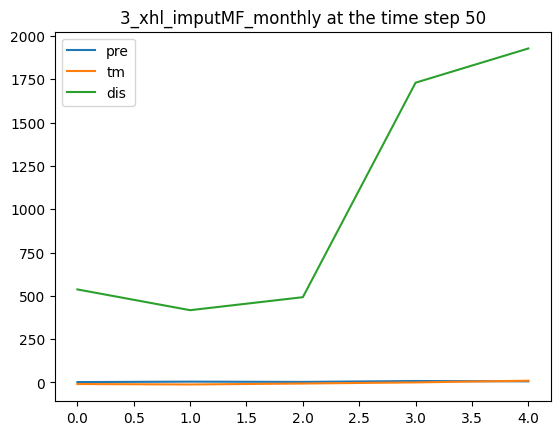

Correlation Coefficient (CC): 0.9124331804984321
Nash-Sutcliffe Efficiency (NSE): 0.8244297215055356
Kling-Gupta Efficiency (KGE): 0.894453232681657
Root-Mean-Square Error (RMSE): 0.09504352044964046
Mean Absolute Relative Error (MARE): 0.358053576508196
Percent Bias (PBIAS): 5.817539302503772
Coefficient of Determination (R²): 0.8244297215055356
1


<ipython-input-110-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - MAE: 0.2776 - loss: 0.1485 - val_MAE: 0.1916 - val_loss: 0.0987
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - MAE: 0.2656 - loss: 0.1420 - val_MAE: 0.1854 - val_loss: 0.0942
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - MAE: 0.2522 - loss: 0.1352 - val_MAE: 0.1818 - val_loss: 0.0885
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - MAE: 0.2414 - loss: 0.1272 - val_MAE: 0.1877 - val_loss: 0.0832
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - MAE: 0.2421 - loss: 0.1194 - val_MAE: 0.2037 - val_loss: 0.0824
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - MAE: 0.2501 - loss: 0.1143 - val_MAE: 0.2000 - val_loss: 0.0781
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - MAE: 0.2432 - loss: 0.1077 - val_MAE: 0.1896 - val_loss: 0.0738
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - MAE: 0.2280 - loss: 0.1014 - val_MAE: 0.1853 - val_loss: 0.0716
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - MAE: 0.2211 -

<ipython-input-132-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


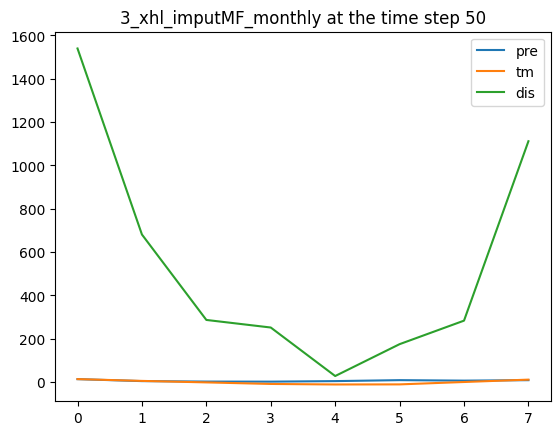

Correlation Coefficient (CC): 0.9082770557961598
Nash-Sutcliffe Efficiency (NSE): 0.8234140067647596
Kling-Gupta Efficiency (KGE): 0.8766749274676268
Root-Mean-Square Error (RMSE): 0.10704863782770985
Mean Absolute Relative Error (MARE): 0.38399513198223006
Percent Bias (PBIAS): 4.3183865509626
Coefficient of Determination (R²): 0.8234140067647596
2


<ipython-input-110-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)


Epoch 1/1000


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - MAE: 0.1846 - loss: 0.0802 - val_MAE: 0.1355 - val_loss: 0.0498
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1725 - loss: 0.0660 - val_MAE: 0.1430 - val_loss: 0.0432
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1605 - loss: 0.0584 - val_MAE: 0.1354 - val_loss: 0.0427
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1569 - loss: 0.0562 - val_MAE: 0.1572 - val_loss: 0.0410
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1643 - loss: 0.0520 - val_MAE: 0.1570 - val_loss: 0.0407
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1607 - loss: 0.0513 - val_MAE: 0.1501 - val_loss: 0.0405
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1579 - loss: 0.0512 - val_MAE: 0.1556 - val_loss: 0.0405
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1600 - loss: 0.0499 - val_MAE: 0.1604 - val_loss: 0.0408
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1616 - loss: 0.0

<ipython-input-132-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


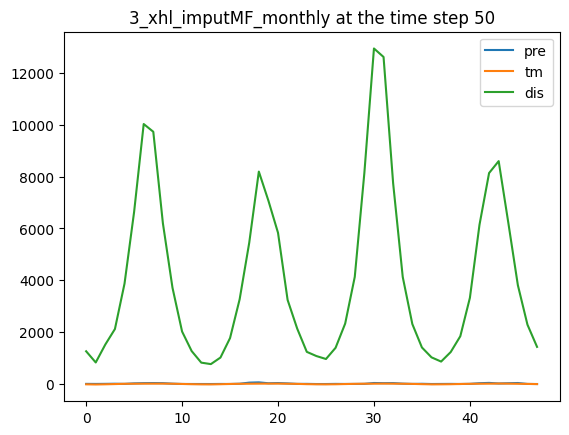

Correlation Coefficient (CC): 0.7858261400601018
Nash-Sutcliffe Efficiency (NSE): 0.605038434327148
Kling-Gupta Efficiency (KGE): 0.6675363271896826
Root-Mean-Square Error (RMSE): 0.12614035694008327
Mean Absolute Relative Error (MARE): 0.5724701383511323
Percent Bias (PBIAS): 15.464163040324394
Coefficient of Determination (R²): 0.605038434327148
3


<ipython-input-110-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)


Epoch 1/1000


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - MAE: 0.1765 - loss: 0.0744 - val_MAE: 0.1349 - val_loss: 0.0362
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1753 - loss: 0.0617 - val_MAE: 0.1269 - val_loss: 0.0317
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1666 - loss: 0.0556 - val_MAE: 0.1407 - val_loss: 0.0308
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.1669 - loss: 0.0513 - val_MAE: 0.1399 - val_loss: 0.0301
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1667 - loss: 0.0493 - val_MAE: 0.1431 - val_loss: 0.0303
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1648 - loss: 0.0485 - val_MAE: 0.1455 - val_loss: 0.0305
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1677 - loss: 0.0480 - val_MAE: 0.1437 - val_loss: 0.0301
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1649 - loss: 0.0472 - val_MAE: 0.1478 - val_loss: 0.0306
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1660 - loss: 0.0

<ipython-input-132-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


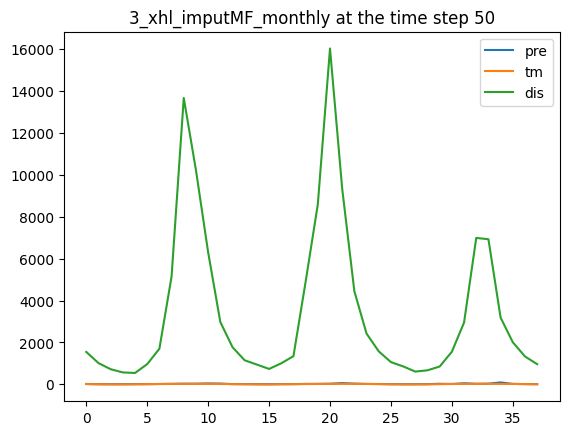

Correlation Coefficient (CC): 0.7759240537257903
Nash-Sutcliffe Efficiency (NSE): 0.5852024401765044
Kling-Gupta Efficiency (KGE): 0.7568207316820469
Root-Mean-Square Error (RMSE): 0.10999511940423351
Mean Absolute Relative Error (MARE): 0.4788286611684498
Percent Bias (PBIAS): -0.5485913185716911
Coefficient of Determination (R²): 0.5852024401765044


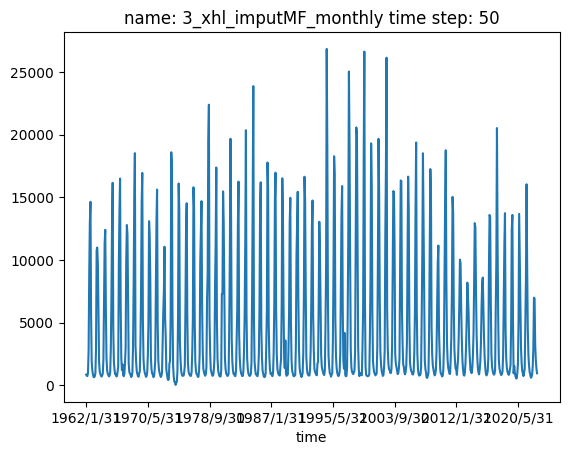

In [140]:
1
# 	i = 0
for i in range(len(null_index_df)):
# for i in [2]:
	print(i)
	intercept_data(i)
	df_scaled=scaler_data(dataFrame)
	X_train, y_train, X_test, y_test , X_forecast = split_data(df_scaled,i)
	multivariate_lstm = model_building(X_train)
	multivariate_lstm,history = model_training(multivariate_lstm, X_train, y_train, X_test, y_test)
	d=medel_predict(multivariate_lstm,  X_test, y_test)
	forecast_df  = forecast_model(multivariate_lstm,X_forecast)
	# d.missing_df(f"F:\geodata\\river_runoff_obs\\5_kq_imputMF{i}.csv")
	CC,NSE,KGE,RMSE,MARE,PBIAS,R2 = model_evaluation(d)
dataFrame_full.index = dataFrame_full.time
dataFrame_full['dis'].plot()
plt.title(f"name: {name} time step: {time_step}")
plt.savefig(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_dataFrame_full_plot.jpg")
plt.show()

dataFrame_full.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_interpolated.csv")

<function matplotlib.pyplot.show(close=None, block=None)>

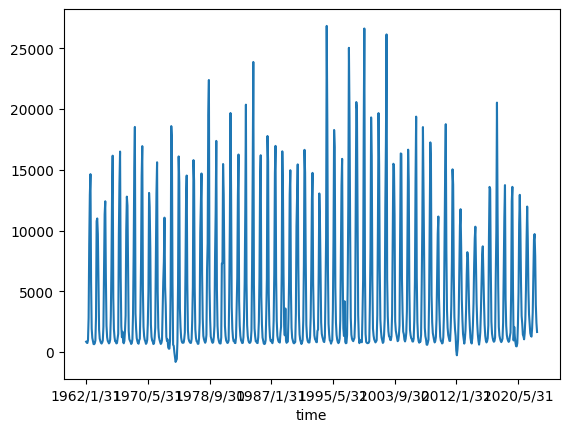

In [137]:
dataFrame_full.index = dataFrame_full.time
dataFrame_full['dis'].plot()
plt.show

In [138]:
dataFrame_full.index = dataFrame_full.time